# Setup D: inclined pipe effective sample size proxy

## 1. Purpose and scope

This notebook develops a first-order engineering proxy for powder renewal and effective sample size during one NIR spectrum acquisition in **Setup D**: an inclined powder pipe with a wall-mounted diffuse-reflectance probe near the lower side of the pipe.

The report focuses on two linked questions:

1. how the pipe flow presents fresh powder past the probe during one acquisition
2. how that presentation, together with an assumed optical penetration depth, sets the refresh-based proxy effective mass $m_{\mathrm{eff,proxy}}$

The reported quantity is a **refresh-based proxy effective mass**, denoted $m_{\mathrm{eff,proxy}}$. It is intended for comparative engineering assessment and sensitivity analysis. It is **not** an exact geometric union of all photon-contributing material, and it is **not** presented as a validated independent sample mass.

## 2. Scientific background

### Optical sampling concept

In diffuse reflectance NIR measurements, light enters a powder bed, interacts with particles over a limited depth, and a fraction of the scattered light returns to the detector. The measured spectrum therefore reflects an **optically weighted near-surface region** rather than the entire bulk stream.

For engineering comparisons, the instantaneous optical interaction region is approximated here as a simple cylinder with:

- cross-sectional area equal to the probe footprint
- depth equal to an assumed optical penetration depth

This simplification ignores depth-dependent photon weighting, scattering anisotropy, packing-dependent path-length effects, and spectral absorption details, but it provides a transparent basis for comparative analysis.

### Probe-flow geometry

In Setup D, the probe is mounted in the pipe wall and looks **radially inward**. The powder flows **axially** along the pipe. These directions are perpendicular.

At any instant, the probe sees a shallow optical disc of powder pressed against the wall:

- the disc face is the **probe footprint** with diameter $d_{\mathrm{probe}}$
- the disc depth is the **optical penetration depth** $d_{\mathrm{pen}}$ extending radially into the powder

Because the probe looks perpendicular to the flow, renewal occurs by material sliding **across** the probe window rather than being pushed **into** it. The flow supplies fresh material axially, while the light samples radially.

### Why a renewal model is appropriate

During one acquisition, the probe does not observe a single static neighborhood of powder. Instead, moving material repeatedly replaces the near-wall region in front of the probe. A renewal model is therefore a natural first-order way to connect powder motion to the mass that can contribute to one spectrum.

### Why superficial velocity is still useful

The notebook uses a **superficial bulk velocity** to estimate the renewal driver from throughput, bulk density, and full pipe cross-sectional area. This is a deliberate engineering approximation: the local wall velocity may differ from the cross-sectional average, but the superficial velocity still provides a transparent transport-side baseline for sensitivity analysis and model comparison.

In [1]:
# 6. Imports
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

In [2]:
# 7. User-defined parameters

pipe_diameter_mm = 65.0  # Pipe internal diameter [mm]
pipe_tilt_deg_from_vertical = 26.5  # Pipe axis tilt from vertical [deg]
pipe_total_height_mm = 340.0  # Total height of the pipe [mm]
pipe_inlet_outlet_displacement_mm = 100.2  # Horizontal displacement from inlet to outlet center [mm]
probe_diameter_mm = 5.0  # NIR probe window diameter [mm]
acquisition_time_s = 1.8  # Spectrum acquisition time [s]

throughput_values_kg_h = list(range(40, 101, 5))  # Throughput sweep [kg/h]
density_values_g_cm3 = [0.4, 0.5, 0.6]  # Bulk density scenarios [g/cm^3]
penetration_depth_values_mm = np.round(np.arange(0.1, 2.0 + 0.1, 0.1), 1)  # Penetration depth sweep [mm]

worked_example_throughput_kg_h = 95.0  # Worked example throughput [kg/h]
worked_example_density_g_cm3 = 0.4  # Worked example bulk density [g/cm^3]

worked_example_penetration_depth_mm = 1.0  # Worked example penetration depth [mm]

## 3. Physical system and engineering context

Setup D is treated as an inclined internal-flow geometry with the following fixed hardware and operating context:

- pipe internal diameter = **65 mm**
- pipe axis tilt = **26.5 degrees from vertical**
- total pipe height = **340 mm**
- horizontal inlet-to-outlet displacement = **100.2 mm**
- NIR probe diameter = **5 mm**
- acquisition time = **1.8 s**

The probe is flush with the lower pipe wall and looks radially inward. Powder moves axially downward through the pipe and is expected to slide preferentially along the lower side, so the probe interacts with a covered near-wall region rather than a free-falling or dilute suspension.

### Expected powder state at the probe

For the modeled operating window, the engineering picture is more consistent with **slow dense-phase sliding** than with dilute pneumatic transport. The practical interpretation is:

- the lower wall is likely to remain covered under normal operating throughputs
- the near-wall material is likely denser and slower than the cross-sectional average
- mild consolidation near the wall is possible
- intermittent exposure could occur only toward the low-throughput edge and is not included in the base model

### Consequence for the base model

The base model therefore uses superficial velocity only as a **first-order renewal driver**. That is reasonable for comparative assessment, but it likely overestimates the local renewal rate if the wall-adjacent powder moves more slowly than the bulk average.

## 4. Model assumptions

The base model is intentionally simple. Its assumptions are grouped below so the reader can see exactly where the engineering approximation enters the calculation.

### Optical and geometric assumptions

- the instantaneous optical sampling region is approximated as a cylinder with volume $A_{\mathrm{probe}} \cdot d_{\mathrm{pen}}$
- the probe window is fully covered by powder at all times
- the probe footprint remains the relevant lateral scale for both the optical proxy and the renewal approximation

### Transport and renewal assumptions

- powder renewal at the probe is approximated by a **first-order renewal approximation** with characteristic axial length of order $d_{\mathrm{probe}}$
- the renewal rate is derived from a **bulk superficial velocity** computed from throughput, density, and full pipe cross-sectional area
- no explicit blocking events or recirculation corrections are included

### Flow-state assumptions

- bulk density is constant and spatially uniform within each scenario
- the powder at the probe is assumed to be in a dense-phase, gravity-driven sliding regime rather than an aerated or fluidized state
- de-aeration during transit through the pipe is assumed but not explicitly modeled
- velocity profiles across the pipe cross-section are not resolved; the superficial velocity represents a bulk average
- local wall velocity may differ from the average superficial velocity, but that difference is ignored in the base model

### Interpretation boundary

- the output is a **refresh-based proxy effective mass** intended for comparative engineering analysis, not a validated independent sample mass

These assumptions intentionally favor transparency and internal consistency over full optical or granular-flow realism.

## 5. Mathematical model

Internal units used throughout the simulation are:

- geometry in **cm**
- area in **cm^2**
- volume in **cm^3**
- time in **s**
- density in **g/cm^3**
- throughput entered in **kg/h** and converted internally to **g/s**
- penetration depth entered in **mm** and converted internally to **cm**
- final reported proxy effective sample masses in **mg**

### Geometric directions at the probe

The probe is mounted in the pipe wall, looking **radially inward**. The powder flows **axially** past the probe. The model uses three perpendicular directions:

| Direction | Symbol | Physical meaning |
|---|---|---|
| **Axial** (along flow) | $v \cdot t_{\mathrm{acq}}$ | distance powder travels during acquisition |
| **Tangential** (in the wall plane) | $d_{\mathrm{probe}}$ | probe footprint width |
| **Radial** (into powder) | $d_{\mathrm{pen}}$ | light penetration depth from wall into powder |

At any single instant, the probe sees a shallow optical disc of powder with face area $A_{\mathrm{probe}}$ and radial depth $d_{\mathrm{pen}}$. Over a finite acquisition, the model does **not** claim that the sampled material is an exact geometric sweep or an exact union. Instead, it uses a **first-order renewal approximation** in which the near-wall powder in front of the probe is refreshed over a characteristic axial length of order $d_{\mathrm{probe}}$.

### Pipe and flow quantities

Pipe cross-sectional area:

$$
A_{\mathrm{pipe}} = \pi \left(\frac{d_{\mathrm{pipe}}}{2}\right)^2
$$

Mass flow conversion:

$$
\dot{m}_{\mathrm{g/s}} = \dot{m}_{\mathrm{kg/h}} \cdot \frac{1000}{3600}
$$

Superficial velocity (axial direction):

$$
v = \frac{\dot{m}}{\rho \cdot A_{\mathrm{pipe}}}
$$

Units: $[\mathrm{g/s}] / ([\mathrm{g/cm^3}] [\mathrm{cm^2}]) = [\mathrm{cm/s}]$.

This is the cross-sectional average axial velocity of the powder along the pipe. In this notebook it is used only as a first-order renewal driver.

**Worked-example check** ($\dot{m} = 95\;\mathrm{kg/h}$, $\rho = 0.4\;\mathrm{g/cm^3}$, $d_{\mathrm{pipe}} = 65\;\mathrm{mm}$):

| Step | Value | Unit |
|---|---|---|
| $\dot{m}$ | $95 \times 1000 / 3600 = 26.3889$ | g/s |
| $A_{\mathrm{pipe}}$ | $\pi (6.5/2)^2 = 33.1831$ | cm^2 |
| $\rho \cdot A_{\mathrm{pipe}}$ | $0.4 \times 33.1831 = 13.2732$ | g/cm |
| $v = \dot{m} / (\rho \cdot A_{\mathrm{pipe}})$ | $26.3889 / 13.2732 = 1.9882$ | cm/s |

### Instantaneous optical mass

Probe footprint area:

$$
A_{\mathrm{probe}} = \pi \left(\frac{d_{\mathrm{probe}}}{2}\right)^2
$$

Instantaneous optical mass:

$$
m_{\mathrm{opt}} = \rho \cdot A_{\mathrm{probe}} \cdot d_{\mathrm{pen}}
$$

This is the instantaneous optically weighted mass adjacent to the probe under the cylindrical optical-volume approximation.

### Refresh factor

The first-order renewal approximation assumes that the powder in front of the probe is refreshed when material advances by a characteristic axial length of order $d_{\mathrm{probe}}$. The corresponding refresh factor during one acquisition is:

$$
N_{\mathrm{refresh}} = \frac{v \cdot t_{\mathrm{acq}}}{d_{\mathrm{probe}}}
$$

This is a renewal-based proxy, not an exact count of independent packets of powder.

### Proxy effective sample mass

The proxy effective sample mass is defined as:

$$
m_{\mathrm{eff,proxy}} = m_{\mathrm{opt}} \cdot N_{\mathrm{refresh}}
$$

Combining the expressions gives:

$$
m_{\mathrm{eff,proxy}} = \rho \cdot A_{\mathrm{probe}} \cdot d_{\mathrm{pen}} \cdot \left(\frac{v \cdot t_{\mathrm{acq}}}{d_{\mathrm{probe}}}\right)
$$

Interpretation of this expression:

- it is a **first-order mechanistic proxy model**
- it assumes renewal of powder over a characteristic length scale of order $d_{\mathrm{probe}}$
- it is **not** the exact geometric union of sampled material
- it is intended for **comparative engineering analysis**

### Convective reference mass-flow proxy

The convective reference mass-flow proxy is a bookkeeping reference quantity: it asks how much powder is presented past the probe footprint during one acquisition under the same superficial-velocity model used elsewhere in the notebook. It ignores optical penetration depth and should **not** be read as an exact 3D sampled volume or an exact geometric union of illuminated powder.

Using the superficial velocity and footprint area defined above,

$$
m_{\mathrm{passed}} = \rho \cdot v \cdot A_{\mathrm{probe}} \cdot t_{\mathrm{acq}}
$$

This is the turnover mass associated with successive probe-footprint-scale neighborhoods being renewed past the probe during one acquisition, under the first-order superficial-velocity model.

**Key assumptions:**

1. The powder is a continuous, uniform stream (no gaps, no clumps).
2. Every bit of powder counted by this turnover reference is included, regardless of whether the light actually reaches it.
3. The speed is the bulk average — powder near the wall might actually move slower.

#### Relation to the effective sample size proxy

The convective reference counts the full footprint-scale mass associated with the renewal process. The optical proxy counts only the shallow optically active mass within that same renewal process:

$$
m_{\mathrm{eff,proxy}} = m_{\mathrm{passed}} \cdot \frac{d_{\mathrm{pen}}}{d_{\mathrm{probe}}}
$$

#### Renewal-event interpretation of the ratio

The factor $d_{\mathrm{pen}} / d_{\mathrm{probe}}$ should **not** be read as "the light penetrates partway through one common slab of thickness $d_{\mathrm{probe}}$." In this model it is the ratio of two proxy masses assigned to the **same renewal event** at the probe.

The shared renewal count is:

$$
N_{\mathrm{refresh}} = \frac{v \cdot t_{\mathrm{acq}}}{d_{\mathrm{probe}}}
$$

For one renewal event, the convective reference counts

$$
m_{\mathrm{event,passed}} = \rho \cdot A_{\mathrm{probe}} \cdot d_{\mathrm{probe}}
$$

while the optical proxy counts

$$
m_{\mathrm{event,optical}} = \rho \cdot A_{\mathrm{probe}} \cdot d_{\mathrm{pen}}
$$

Multiplying both by the same renewal count gives

$$
m_{\mathrm{passed}} = N_{\mathrm{refresh}} \cdot \rho \cdot A_{\mathrm{probe}} \cdot d_{\mathrm{probe}}
$$

$$
m_{\mathrm{eff,proxy}} = N_{\mathrm{refresh}} \cdot \rho \cdot A_{\mathrm{probe}} \cdot d_{\mathrm{pen}}
$$

so that

$$
\frac{m_{\mathrm{eff,proxy}}}{m_{\mathrm{passed}}} = \frac{d_{\mathrm{pen}}}{d_{\mathrm{probe}}}
$$

The two quantities share the same $\rho$, $A_{\mathrm{probe}}$, and $N_{\mathrm{refresh}}$. The only substituted length is the characteristic depth assigned to one renewal event.

#### Cross-directional meaning of the ratio

The ratio compares a **radial optical depth** to an **axial renewal length**:

- **axial** motion sets the renewal count
- **tangential** extent contributes to the footprint area $A_{\mathrm{probe}}$
- **radial** extent sets the optical mass counted within each renewal event

The ratio works because the model compares two bookkeeping definitions built on the same renewal process, not because the light literally penetrates a fraction of the way through an axial slab. The schematic below makes that distinction explicit.

#### Why $d_{\mathrm{probe}}$ appears in the denominator

The denominator is $d_{\mathrm{probe}}$ because the renewal count is defined at the **probe-footprint scale**:

$$
N_{\mathrm{refresh}} = \frac{v \cdot t_{\mathrm{acq}}}{d_{\mathrm{probe}}}
$$

The model asks how many probe-sized renewal events occur during one acquisition, not how many pipe-diameter-length events occur.

#### Numerical check with worked example

Using the worked example ($d_{\mathrm{pen}} = 1\;\mathrm{mm}$, $d_{\mathrm{probe}} = 5\;\mathrm{mm}$):

$$
\frac{d_{\mathrm{pen}}}{d_{\mathrm{probe}}} = \frac{1}{5} = 0.2
$$

So, for each renewal event, the optical proxy counts one-fifth of the mass counted by the convective reference because it uses $d_{\mathrm{pen}}$ instead of $d_{\mathrm{probe}}$.

#### Summary of the three related quantities

| Quantity | What it answers | Formula |
|---|---|---|
| $v$ | How fast is the powder moving? | $\dot{m} / (\rho \cdot A_{\mathrm{pipe}})$ |
| $m_{\mathrm{passed}}$ | How much powder is presented past the probe footprint under the convective reference model? | $\rho \cdot v \cdot A_{\mathrm{probe}} \cdot t_{\mathrm{acq}}$ |
| $m_{\mathrm{eff,proxy}}$ | How much mass is counted by the optical renewal proxy? | $m_{\mathrm{passed}} \cdot d_{\mathrm{pen}} / d_{\mathrm{probe}}$ |

The ratio $d_{\mathrm{pen}} / d_{\mathrm{probe}}$ is therefore a bookkeeping consequence of the proxy model. Its value is to keep the convective reference and the optical proxy conceptually separate.

### Density cancellation within this model

The superficial velocity relation is:

$$
v = \frac{\dot{m}}{\rho \cdot A_{\mathrm{pipe}}}
$$

Substituting into the proxy effective-mass expression gives:

$$
m_{\mathrm{eff,proxy}} = \rho \cdot A_{\mathrm{probe}} \cdot d_{\mathrm{pen}} \cdot \left(\frac{v \cdot t_{\mathrm{acq}}}{d_{\mathrm{probe}}}\right)
$$

$$
m_{\mathrm{eff,proxy}} = \left(\frac{A_{\mathrm{probe}} \cdot d_{\mathrm{pen}} \cdot t_{\mathrm{acq}}}{d_{\mathrm{probe}} \cdot A_{\mathrm{pipe}}}\right) \cdot \dot{m}
$$

In this model, the density terms cancel exactly. That cancellation is **model-dependent**: it follows from using the same bulk density in both the instantaneous optical mass and the superficial-velocity approximation.

This cancellation is worth understanding because it is one of the sharpest internal consistency checks in the notebook. At fixed mass throughput, increasing density does two equal and opposite things within this formulation: it increases the instantaneous optical mass, but it decreases the renewal rate by the same factor through the superficial-velocity relation. If a reader misses that cancellation, they will misread the model and attribute density sensitivity to a proxy that, by construction, does not contain it. Seeing the cancellation tells you exactly what the current model captures, and exactly which additional physics would need to be added before density could matter again.

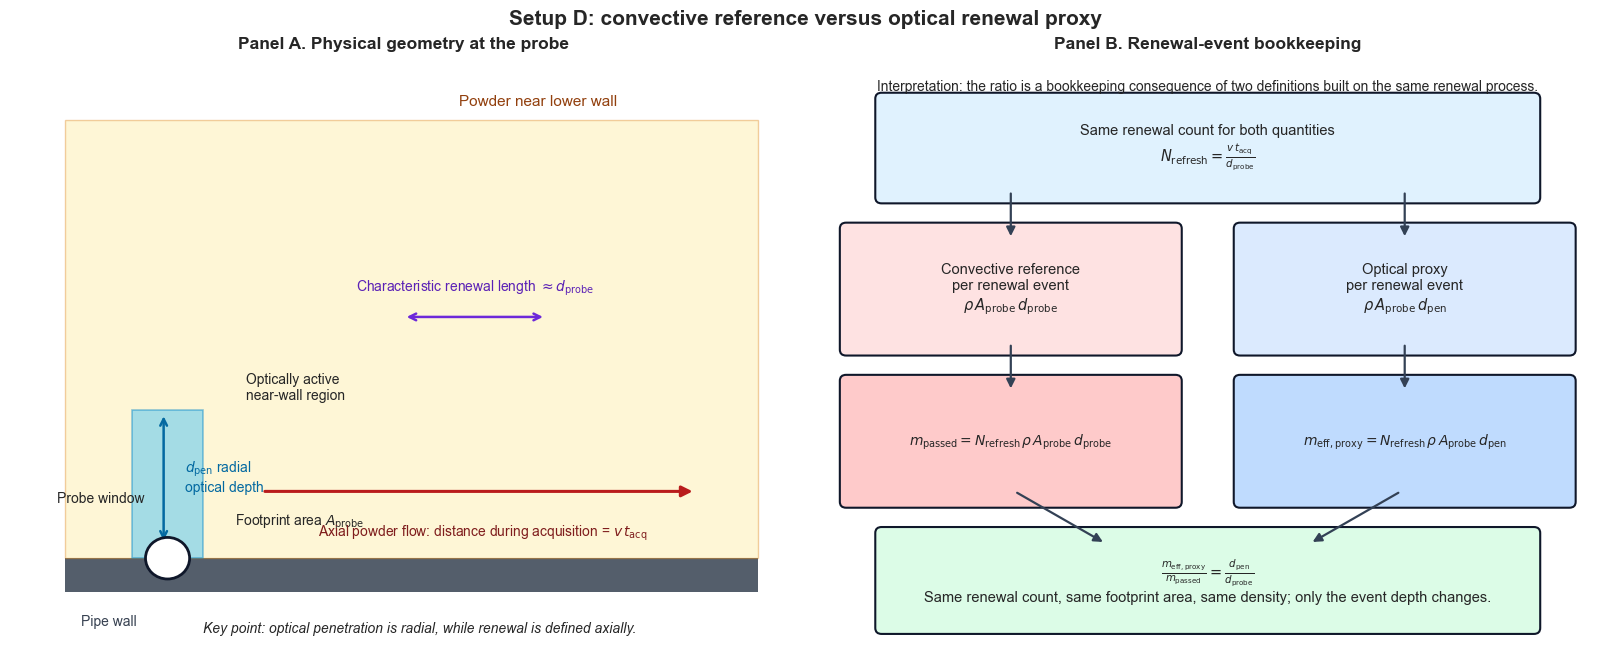

In [3]:
# Two-panel schematic: physical geometry and renewal-event bookkeeping
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, FancyArrowPatch, FancyBboxPatch

fig_setup_d_schematic, axes = plt.subplots(1, 2, figsize=(16, 6.5), constrained_layout=True)
fig_setup_d_schematic.suptitle(
    'Setup D: convective reference versus optical renewal proxy',
    fontsize=15,
    fontweight='bold',
)

for ax in axes:
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 8)
    ax.axis('off')

# Panel A: physical geometry at the probe
ax = axes[0]
ax.set_title('Panel A. Physical geometry at the probe', fontsize=12.5, fontweight='bold')

# Pipe wall and powder region
ax.add_patch(Rectangle((0.7, 0.8), 8.8, 0.45, facecolor='#4b5563', edgecolor='none', alpha=0.95))
ax.text(0.9, 0.35, 'Pipe wall', fontsize=10, color='#374151')
ax.add_patch(Rectangle((0.7, 1.25), 8.8, 5.9, facecolor='#fde68a', edgecolor='#d97706', linewidth=1.0, alpha=0.35))
ax.text(6.7, 7.35, 'Powder near lower wall', fontsize=11, ha='center', color='#92400e')

# Probe window at the lower wall
probe_center = (2.0, 1.25)
ax.add_patch(Circle(probe_center, 0.28, facecolor='white', edgecolor='#0f172a', linewidth=2.0, zorder=5))
ax.text(1.15, 2.0, 'Probe window', fontsize=10, ha='center')
ax.text(2.85, 1.7, r'Footprint area $A_{\mathrm{probe}}$', fontsize=10, ha='left')

# Optical near-wall region
ax.add_patch(Rectangle((1.55, 1.25), 0.9, 2.0, facecolor='#38bdf8', edgecolor='#0284c7', linewidth=1.2, alpha=0.45))
ax.text(3.0, 3.55, 'Optically active\nnear-wall region'.replace('\\n', '\n'), fontsize=10, va='center')

# Radial penetration arrow
ax.add_patch(FancyArrowPatch((1.95, 1.45), (1.95, 3.2), arrowstyle='<->', mutation_scale=12, linewidth=1.8, color='#0369a1'))
ax.text(2.22, 2.35, r'$d_{\mathrm{pen}}$ radial' + '\n' + 'optical depth', fontsize=10, color='#0369a1', va='center')

# Axial flow arrow and travel distance
ax.add_patch(FancyArrowPatch((3.2, 2.15), (8.7, 2.15), arrowstyle='-|>', mutation_scale=16, linewidth=2.2, color='#b91c1c'))
ax.text(6.0, 1.55, r'Axial powder flow: distance during acquisition = $v\,t_{\mathrm{acq}}$', fontsize=10, color='#7f1d1d', ha='center')

# Characteristic renewal length
ax.add_patch(FancyArrowPatch((5.0, 4.5), (6.8, 4.5), arrowstyle='<->', mutation_scale=12, linewidth=1.8, color='#6d28d9'))
ax.text(5.9, 4.85, r'Characteristic renewal length $\approx d_{\mathrm{probe}}$', fontsize=10, color='#5b21b6', ha='center')

ax.text(
    5.2,
    0.25,
    'Key point: optical penetration is radial, while renewal is defined axially.',
    fontsize=10,
    ha='center',
    style='italic',
)

# Panel B: bookkeeping for one renewal event
ax = axes[1]
ax.set_title('Panel B. Renewal-event bookkeeping', fontsize=12.5, fontweight='bold')


def add_box(ax, x, y, width, height, text, facecolor, edgecolor='#0f172a', fontsize=10):
    box = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle='round,pad=0.22,rounding_size=0.08',
        linewidth=1.5,
        facecolor=facecolor,
        edgecolor=edgecolor,
    )
    ax.add_patch(box)
    ax.text(x + width / 2, y + height / 2, text, ha='center', va='center', fontsize=fontsize)
    return box

add_box(
    ax,
    1.0,
    6.25,
    8.0,
    1.05,
    'Same renewal count for both quantities\n' + r'$N_{\mathrm{refresh}} = \frac{v\,t_{\mathrm{acq}}}{d_{\mathrm{probe}}}$',
    '#e0f2fe',
    fontsize=10.5,
)

add_box(
    ax,
    0.55,
    4.2,
    3.9,
    1.35,
    'Convective reference\nper renewal event\n' + r'$\rho\,A_{\mathrm{probe}}\,d_{\mathrm{probe}}$',
    '#fee2e2',
    fontsize=10.5,
)
add_box(
    ax,
    5.55,
    4.2,
    3.9,
    1.35,
    'Optical proxy\nper renewal event\n' + r'$\rho\,A_{\mathrm{probe}}\,d_{\mathrm{pen}}$',
    '#dbeafe',
    fontsize=10.5,
)

add_box(
    ax,
    0.55,
    2.15,
    3.9,
    1.35,
    r'$m_{\mathrm{passed}} = N_{\mathrm{refresh}}\,\rho\,A_{\mathrm{probe}}\,d_{\mathrm{probe}}$',
    '#fecaca',
    fontsize=10,
)
add_box(
    ax,
    5.55,
    2.15,
    3.9,
    1.35,
    r'$m_{\mathrm{eff,proxy}} = N_{\mathrm{refresh}}\,\rho\,A_{\mathrm{probe}}\,d_{\mathrm{pen}}$',
    '#bfdbfe',
    fontsize=10,
)

add_box(
    ax,
    1.0,
    0.45,
    8.0,
    1.0,
    r'$\frac{m_{\mathrm{eff,proxy}}}{m_{\mathrm{passed}}} = \frac{d_{\mathrm{pen}}}{d_{\mathrm{probe}}}$'
    + '\n'
    + 'Same renewal count, same footprint area, same density; only the event depth changes.',
    '#dcfce7',
    fontsize=10.5,
)

for start, end in [
    ((2.5, 6.2), (2.5, 5.55)),
    ((7.5, 6.2), (7.5, 5.55)),
    ((2.5, 4.15), (2.5, 3.5)),
    ((7.5, 4.15), (7.5, 3.5)),
    ((2.55, 2.15), (3.7, 1.45)),
    ((7.45, 2.15), (6.3, 1.45)),
]:
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle='-|>', mutation_scale=13, linewidth=1.6, color='#334155'))

ax.text(
    5.0,
    7.55,
    'Interpretation: the ratio is a bookkeeping consequence of two definitions built on the same renewal process.',
    fontsize=10,
    ha='center',
)

plt.show()

In [4]:
# 8. Helper functions

def _validate_positive(value, name):
    """Raise a ValueError if value is not strictly positive."""
    if value <= 0:
        raise ValueError(f'{name} must be positive; received {value!r}.')


def mm_to_cm(mm):
    """Convert millimeters to centimeters."""
    _validate_positive(mm, 'mm')
    return mm / 10.0


def kg_h_to_g_s(kg_h):
    """Convert mass flow from kilograms per hour to grams per second."""
    _validate_positive(kg_h, 'kg_h')
    return kg_h * 1000.0 / 3600.0


def pipe_cross_section_area_cm2(pipe_diameter_cm):
    """Return pipe cross-sectional area in cm^2."""
    _validate_positive(pipe_diameter_cm, 'pipe_diameter_cm')
    radius_cm = pipe_diameter_cm / 2.0
    return math.pi * radius_cm**2


def probe_area_cm2(probe_diameter_cm):
    """Return probe footprint area in cm^2."""
    _validate_positive(probe_diameter_cm, 'probe_diameter_cm')
    radius_cm = probe_diameter_cm / 2.0
    return math.pi * radius_cm**2


def superficial_velocity_cm_s(throughput_kg_h, density_g_cm3, pipe_diameter_cm):
    """Estimate superficial bulk velocity in the pipe in cm/s."""
    _validate_positive(density_g_cm3, 'density_g_cm3')
    throughput_g_s = kg_h_to_g_s(kg_h=throughput_kg_h)
    area_cm2 = pipe_cross_section_area_cm2(pipe_diameter_cm)
    return throughput_g_s / (density_g_cm3 * area_cm2)


def optical_volume_cm3(probe_diameter_cm, penetration_depth_cm):
    """Return static optical interaction volume in cm^3."""
    _validate_positive(penetration_depth_cm, 'penetration_depth_cm')
    return probe_area_cm2(probe_diameter_cm) * penetration_depth_cm


def optical_mass_g(density_g_cm3, probe_diameter_cm, penetration_depth_cm):
    """Return instantaneous optical mass in grams."""
    _validate_positive(density_g_cm3, 'density_g_cm3')
    return density_g_cm3 * optical_volume_cm3(probe_diameter_cm, penetration_depth_cm)


def crossing_time_s(probe_diameter_cm, velocity_cm_s):
    """Return time for material to move one characteristic probe diameter in seconds."""
    _validate_positive(probe_diameter_cm, 'probe_diameter_cm')
    _validate_positive(velocity_cm_s, 'velocity_cm_s')
    return probe_diameter_cm / velocity_cm_s


def passed_volume_cm3(velocity_cm_s, probe_diameter_cm, acquisition_time_s):
    """Return the convective reference volume-flow proxy during one acquisition in cm^3."""
    _validate_positive(acquisition_time_s, 'acquisition_time_s')
    _validate_positive(velocity_cm_s, 'velocity_cm_s')
    return velocity_cm_s * probe_area_cm2(probe_diameter_cm) * acquisition_time_s


def passed_mass_mg(density_g_cm3, velocity_cm_s, probe_diameter_cm, acquisition_time_s):
    """Return the convective reference mass-flow proxy during one acquisition in mg."""
    _validate_positive(density_g_cm3, 'density_g_cm3')
    volume_cm3 = passed_volume_cm3(velocity_cm_s, probe_diameter_cm, acquisition_time_s)
    return density_g_cm3 * volume_cm3 * 1000.0


def effective_sample_mass_estimate_mg(
    throughput_kg_h,
    density_g_cm3,
    pipe_diameter_cm,
    probe_diameter_cm,
    penetration_depth_cm,
    acquisition_time_s,
):
    """Return a dictionary of first-order proxy effective-mass quantities."""
    velocity_cm_s = superficial_velocity_cm_s(throughput_kg_h, density_g_cm3, pipe_diameter_cm)
    optical_mass_per_refresh_g = optical_mass_g(density_g_cm3, probe_diameter_cm, penetration_depth_cm)
    t_cross_s = crossing_time_s(probe_diameter_cm, velocity_cm_s)
    n_refresh = acquisition_time_s / t_cross_s
    effective_mass_estimate_mg = optical_mass_per_refresh_g * n_refresh * 1000.0  # proxy effective mass

    return {
        'superficial_velocity_cm_s': velocity_cm_s,
        'optical_mass_per_refresh_g': optical_mass_per_refresh_g,
        'crossing_time_s': t_cross_s,
        'n_refresh': n_refresh,
        'effective_sample_mass_estimate_mg': effective_mass_estimate_mg,
    }

## 9. Single-case worked example

The worked example anchors the later parameter sweep in one concrete operating point. Its role is to show the magnitude of the transport term, the optical term, the refresh factor, and the resulting proxy effective mass before moving to the full design space.

The calculation below uses:

- throughput = **95 kg/h**
- density = **0.4 g/cm^3**
- pipe diameter = **65 mm**
- pipe tilt = **26.5 degrees from vertical**
- probe diameter = **5 mm**
- penetration depth = **1.0 mm**
- acquisition time = **1.8 s**

This example should be read as a sanity check of the first-order model, not as a validated local wall-flow measurement. In a real tilted pipe, the local lower-wall velocity may differ from the superficial velocity used here as the renewal driver.

In [5]:
pipe_diameter_cm = mm_to_cm(pipe_diameter_mm)
probe_diameter_cm = mm_to_cm(probe_diameter_mm)
penetration_depth_cm = mm_to_cm(worked_example_penetration_depth_mm)

pipe_area_cm2 = pipe_cross_section_area_cm2(pipe_diameter_cm)
throughput_g_s = kg_h_to_g_s(worked_example_throughput_kg_h)
velocity_cm_s = superficial_velocity_cm_s(
    worked_example_throughput_kg_h,
    worked_example_density_g_cm3,
    pipe_diameter_cm,
)
probe_area_value_cm2 = probe_area_cm2(probe_diameter_cm)
optical_volume_value_cm3 = optical_volume_cm3(probe_diameter_cm, penetration_depth_cm)
optical_mass_value_g = optical_mass_g(
    worked_example_density_g_cm3,
    probe_diameter_cm,
    penetration_depth_cm,
)
crossing_time_value_s = crossing_time_s(probe_diameter_cm, velocity_cm_s)
n_refresh_value = acquisition_time_s / crossing_time_value_s
effective_estimate = effective_sample_mass_estimate_mg(
    worked_example_throughput_kg_h,
    worked_example_density_g_cm3,
    pipe_diameter_cm,
    probe_diameter_cm,
    penetration_depth_cm,
    acquisition_time_s,
)
passed_volume_value_cm3 = passed_volume_cm3(velocity_cm_s, probe_diameter_cm, acquisition_time_s)
passed_mass_value_mg = passed_mass_mg(
    worked_example_density_g_cm3,
    velocity_cm_s,
    probe_diameter_cm,
    acquisition_time_s,
)

print('Worked example: Setup D first-order renewal proxy')
print(f'Pipe tilt from vertical: {pipe_tilt_deg_from_vertical:.1f} deg')
print(f'Pipe cross-sectional area: {pipe_area_cm2:.4f} cm^2')
print(f'Throughput: {throughput_g_s:.4f} g/s')
print(f'Superficial velocity: {velocity_cm_s:.4f} cm/s')
print(f'Probe area: {probe_area_value_cm2:.6f} cm^2')
print(f'Instantaneous optical volume: {optical_volume_value_cm3:.6f} cm^3')
print(f'Instantaneous optical mass: {optical_mass_value_g * 1000.0:.4f} mg')
print(f'Characteristic crossing time: {crossing_time_value_s:.4f} s')
print(f'Refresh factor during acquisition: {n_refresh_value:.4f}')
print(f"Effective sample size proxy: {effective_estimate['effective_sample_mass_estimate_mg']:.4f} mg")
print(f'Convective reference volume-flow proxy: {passed_volume_value_cm3:.6f} cm^3')
print(f'Convective reference mass-flow proxy: {passed_mass_value_mg:.4f} mg')

Worked example: Setup D first-order renewal proxy
Pipe tilt from vertical: 26.5 deg
Pipe cross-sectional area: 33.1831 cm^2
Throughput: 26.3889 g/s
Superficial velocity: 1.9881 cm/s
Probe area: 0.196350 cm^2
Instantaneous optical volume: 0.019635 cm^3
Instantaneous optical mass: 7.8540 mg
Characteristic crossing time: 0.2515 s
Refresh factor during acquisition: 7.1573
Effective sample size proxy: 56.2130 mg
Convective reference volume-flow proxy: 0.702663 cm^3
Convective reference mass-flow proxy: 281.0651 mg


## 10. Model scenarios and sweep design

After the worked example, the notebook expands to a structured sweep designed to answer three questions:

1. how throughput changes the renewal rate
2. how penetration depth changes the instantaneous optical mass
3. whether density changes the final proxy once the superficial-velocity relation is applied

The sweep spans:

- throughput from **40 to 100 kg/h**
- density = **0.4, 0.5, 0.6 g/cm^3**
- penetration depth from **0.1 to 2.0 mm** in **0.1 mm** steps
- probe diameter fixed at **5 mm**
- acquisition time fixed at **1.8 s**

Detailed outputs are exported to CSV. The notebook itself shows only the selected tables and figures needed to support the engineering interpretation.

In [6]:
records = []

pipe_diameter_cm = mm_to_cm(pipe_diameter_mm)
probe_diameter_cm = mm_to_cm(probe_diameter_mm)
pipe_area_cm2_value = pipe_cross_section_area_cm2(pipe_diameter_cm)

for throughput_kg_h in throughput_values_kg_h:
    throughput_g_s = kg_h_to_g_s(throughput_kg_h)
    for density_g_cm3 in density_values_g_cm3:
        velocity_cm_s = superficial_velocity_cm_s(throughput_kg_h, density_g_cm3, pipe_diameter_cm)
        t_cross_s = crossing_time_s(probe_diameter_cm, velocity_cm_s)
        n_refresh = acquisition_time_s / t_cross_s
        passed_volume_value_cm3 = passed_volume_cm3(velocity_cm_s, probe_diameter_cm, acquisition_time_s)
        passed_mass_value_mg = passed_mass_mg(density_g_cm3, velocity_cm_s, probe_diameter_cm, acquisition_time_s)

        for penetration_depth_mm in penetration_depth_values_mm:
            penetration_depth_cm = mm_to_cm(float(penetration_depth_mm))
            estimate = effective_sample_mass_estimate_mg(
                throughput_kg_h,
                density_g_cm3,
                pipe_diameter_cm,
                probe_diameter_cm,
                penetration_depth_cm,
                acquisition_time_s,
            )
            optical_mass_per_refresh_mg = (
                optical_mass_g(density_g_cm3, probe_diameter_cm, penetration_depth_cm) * 1000.0
            )

            records.append(
                {
                    'throughput_kg_h': throughput_kg_h,
                    'density_g_cm3': density_g_cm3,
                    'pipe_diameter_mm': pipe_diameter_mm,
                    'pipe_tilt_deg_from_vertical': pipe_tilt_deg_from_vertical,
                    'penetration_depth_mm': float(penetration_depth_mm),
                    'probe_diameter_mm': probe_diameter_mm,
                    'acquisition_time_s': acquisition_time_s,
                    'throughput_g_s': throughput_g_s,
                    'pipe_area_cm2': pipe_area_cm2_value,
                    'superficial_velocity_cm_s': velocity_cm_s,
                    'optical_mass_per_refresh_mg': optical_mass_per_refresh_mg,
                    'crossing_time_s': t_cross_s,
                    'n_refresh': n_refresh,
                    'effective_sample_mass_estimate_mg': estimate['effective_sample_mass_estimate_mg'],
                    'passed_volume_cm3': passed_volume_value_cm3,
                    'passed_mass_mg': passed_mass_value_mg,
                }
            )

results_df = pd.DataFrame(records)
results_df = results_df.sort_values(
    ['density_g_cm3', 'throughput_kg_h', 'penetration_depth_mm'], ignore_index=True
)

print(f'Generated {len(results_df)} modeled scenarios.')


Generated 780 modeled scenarios.


## 11. Selected results tables

The table below is intentionally curated for report reading. It samples low, mid, and high throughput, all three density scenarios, and representative penetration depths. Full scenario tables are exported separately as CSV files.

In [7]:
selected_scenarios = results_df[
    results_df['throughput_kg_h'].isin([40, 70, 100])
    & results_df['density_g_cm3'].isin([0.4, 0.5, 0.6])
    & results_df['penetration_depth_mm'].isin([0.5, 1.0, 2.0])
].copy()

selected_scenarios_display = (
    selected_scenarios[
        [
            'throughput_kg_h',
            'density_g_cm3',
            'penetration_depth_mm',
            'superficial_velocity_cm_s',
            'optical_mass_per_refresh_mg',
            'n_refresh',
            'effective_sample_mass_estimate_mg',
            'passed_mass_mg',
        ]
    ]
    .rename(
        columns={
            'effective_sample_mass_estimate_mg': 'effective_sample_mass_proxy_mg',
            'passed_mass_mg': 'convective_reference_mass_proxy_mg',
        }
    )
    .reset_index(drop=True)
)

selected_scenarios_display

,throughput_kg_h,density_g_cm3,penetration_depth_mm,superficial_velocity_cm_s,optical_mass_per_refresh_mg,n_refresh,effective_sample_mass_proxy_mg,convective_reference_mass_proxy_mg
0,40,0.4000,0.5000,0.8371,3.9270,3.0136,11.8343,118.3432
1,40,0.4000,1.0000,0.8371,7.8540,3.0136,23.6686,118.3432
2,40,0.4000,2.0000,0.8371,15.7080,3.0136,47.3373,118.3432
3,70,0.4000,0.5000,1.4649,3.9270,5.2738,20.7101,207.1006
4,70,0.4000,1.0000,1.4649,7.8540,5.2738,41.4201,207.1006
5,70,0.4000,2.0000,1.4649,15.7080,5.2738,82.8402,207.1006
6,100,0.4000,0.5000,2.0928,3.9270,7.5340,29.5858,295.8580
7,100,0.4000,1.0000,2.0928,7.8540,7.5340,59.1716,295.8580
8,100,0.4000,2.0000,2.0928,15.7080,7.5340,118.3432,295.8580
9,40,0.5000,0.5000,0.6697,4.9087,2.4109,11.8343,118.3432


In [8]:
pivot_density_04 = results_df[results_df['density_g_cm3'] == 0.4].pivot(
    index='penetration_depth_mm',
    columns='throughput_kg_h',
    values='effective_sample_mass_estimate_mg',
)

## 12. Visualization

The figures are ordered from **mechanism** to **outcome** so the reader sees how the proxy is built before seeing the final effective-mass response:

1. transport driver: superficial velocity
2. optical-side mass per renewal event
3. convective reference mass presentation
4. effective sample size proxy versus penetration depth
5. effective sample size proxy versus throughput
6. a two-dimensional summary surface for the proxy

This ordering is intentional and is meant to support the logic of the engineering assessment.

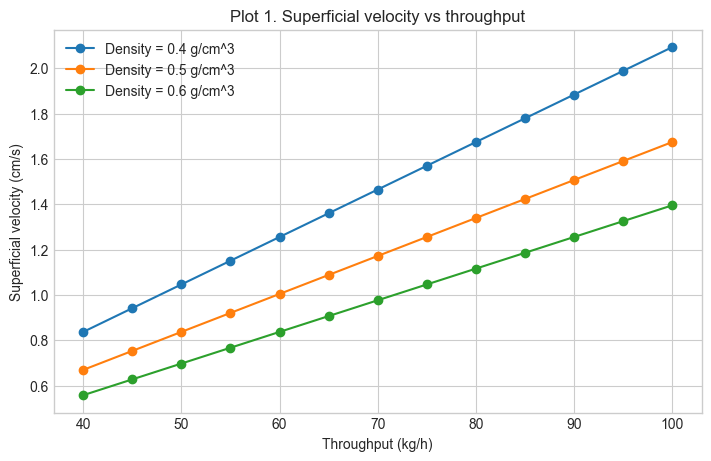

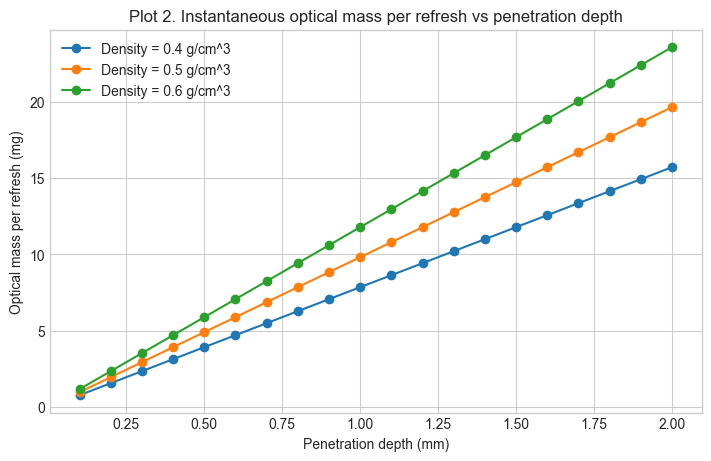

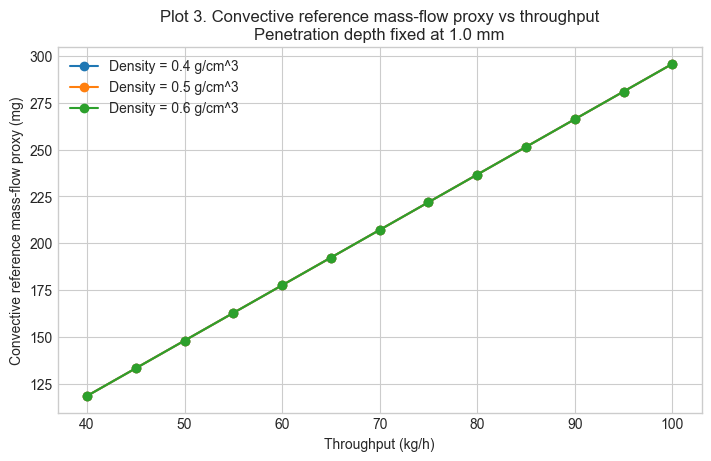

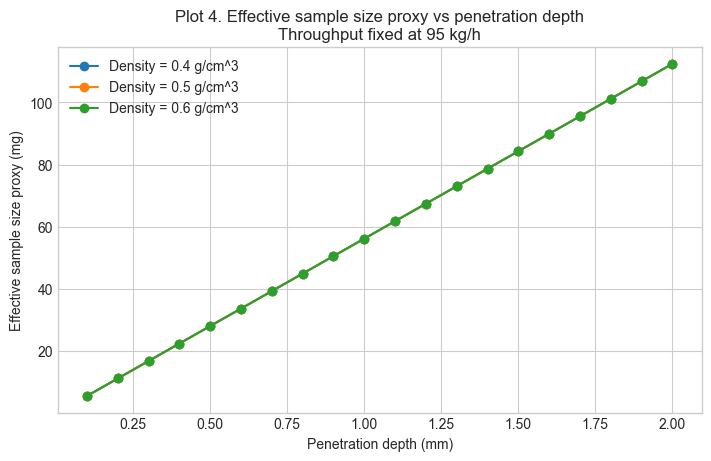

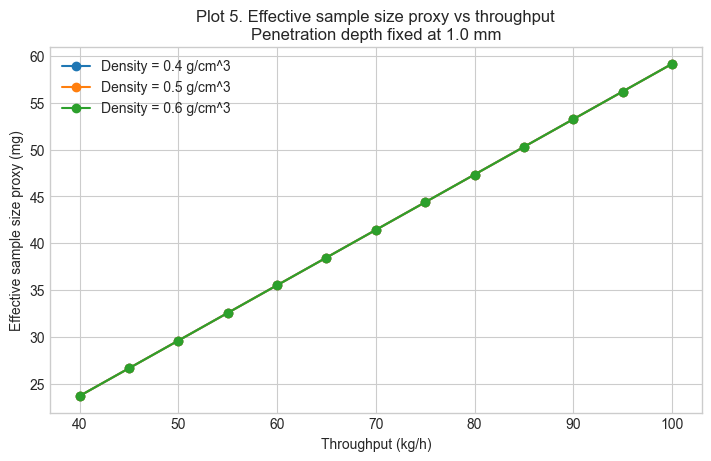

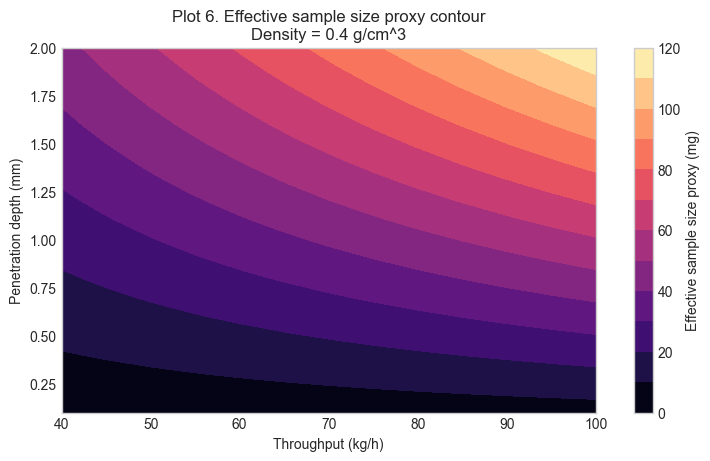

In [9]:
# Plot 1: superficial velocity vs throughput
fig_setup_d_plot_01, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
velocity_plot_df = (
    results_df[['throughput_kg_h', 'density_g_cm3', 'superficial_velocity_cm_s']]
    .drop_duplicates()
    .sort_values(['density_g_cm3', 'throughput_kg_h'])
)
for density in density_values_g_cm3:
    subset = velocity_plot_df[velocity_plot_df['density_g_cm3'] == density]
    ax.plot(
        subset['throughput_kg_h'],
        subset['superficial_velocity_cm_s'],
        marker='o',
        label=f'Density = {density:.1f} g/cm^3',
    )
ax.set_title('Plot 1. Superficial velocity vs throughput')
ax.set_xlabel('Throughput (kg/h)')
ax.set_ylabel('Superficial velocity (cm/s)')
ax.legend()
plt.show()

# Plot 2: instantaneous optical mass per refresh vs penetration depth
fig_setup_d_plot_02, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
plot2_df = results_df[results_df['throughput_kg_h'] == 70]
for density in density_values_g_cm3:
    subset = plot2_df[plot2_df['density_g_cm3'] == density]
    ax.plot(
        subset['penetration_depth_mm'],
        subset['optical_mass_per_refresh_mg'],
        marker='o',
        label=f'Density = {density:.1f} g/cm^3',
    )
ax.set_title('Plot 2. Instantaneous optical mass per refresh vs penetration depth')
ax.set_xlabel('Penetration depth (mm)')
ax.set_ylabel('Optical mass per refresh (mg)')
ax.legend()
plt.show()

# Plot 3: convective reference mass-flow proxy vs throughput
fig_setup_d_plot_03, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
plot3_df = results_df[np.isclose(results_df['penetration_depth_mm'], 1.0)]
for density in density_values_g_cm3:
    subset = plot3_df[plot3_df['density_g_cm3'] == density]
    ax.plot(
        subset['throughput_kg_h'],
        subset['passed_mass_mg'],
        marker='o',
        label=f'Density = {density:.1f} g/cm^3',
    )
ax.set_title('Plot 3. Convective reference mass-flow proxy vs throughput\nPenetration depth fixed at 1.0 mm')
ax.set_xlabel('Throughput (kg/h)')
ax.set_ylabel('Convective reference mass-flow proxy (mg)')
ax.legend()
plt.show()

# Plot 4: effective sample size proxy vs penetration depth at fixed throughput
fig_setup_d_plot_04, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
plot4_df = results_df[results_df['throughput_kg_h'] == 95]
for density in density_values_g_cm3:
    subset = plot4_df[plot4_df['density_g_cm3'] == density]
    ax.plot(
        subset['penetration_depth_mm'],
        subset['effective_sample_mass_estimate_mg'],
        marker='o',
        label=f'Density = {density:.1f} g/cm^3',
    )
ax.set_title('Plot 4. Effective sample size proxy vs penetration depth\nThroughput fixed at 95 kg/h')
ax.set_xlabel('Penetration depth (mm)')
ax.set_ylabel('Effective sample size proxy (mg)')
ax.legend()
plt.show()

# Plot 5: effective sample size proxy vs throughput at fixed penetration depth
fig_setup_d_plot_05, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
plot5_df = results_df[np.isclose(results_df['penetration_depth_mm'], 1.0)]
for density in density_values_g_cm3:
    subset = plot5_df[plot5_df['density_g_cm3'] == density]
    ax.plot(
        subset['throughput_kg_h'],
        subset['effective_sample_mass_estimate_mg'],
        marker='o',
        label=f'Density = {density:.1f} g/cm^3',
    )
ax.set_title('Plot 5. Effective sample size proxy vs throughput\nPenetration depth fixed at 1.0 mm')
ax.set_xlabel('Throughput (kg/h)')
ax.set_ylabel('Effective sample size proxy (mg)')
ax.legend()
plt.show()

# Plot 6: effective sample size proxy contour for density 0.4 g/cm^3
fig_setup_d_plot_06, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
T, P = np.meshgrid(pivot_density_04.columns.to_numpy(), pivot_density_04.index.to_numpy())
contour = ax.contourf(T, P, pivot_density_04.values, levels=12, cmap='magma')
ax.set_title('Plot 6. Effective sample size proxy contour\nDensity = 0.4 g/cm^3')
ax.set_xlabel('Throughput (kg/h)')
ax.set_ylabel('Penetration depth (mm)')
fig_setup_d_plot_06.colorbar(contour, ax=ax, label='Effective sample size proxy (mg)')
plt.show()

## 13. Interpretation of trends

The reordered figures are meant to be read as a causal chain from transport to optical sampling to the final proxy response.

1. **Transport driver.** Plot 1 shows that superficial velocity increases with throughput and decreases with density for fixed mass throughput.
2. **Optical contribution per renewal event.** Plot 2 shows that deeper penetration and higher density increase the instantaneous optical mass associated with one renewal event.
3. **Transport-side reference mass.** Plot 3 shows the convective reference mass-flow proxy. Within the present formulation it scales with throughput and is density independent because the same $\rho$ that raises mass per volume also lowers superficial velocity.
4. **Combined proxy response.** Plots 4 and 5 show that the effective sample size proxy increases with both penetration depth and throughput.
5. **Two-dimensional summary.** Plot 6 compresses the joint dependence on throughput and penetration depth into one representative response surface.

### Why density cancels within this model

In this model, density enters in two places that act in opposite directions.

**Effect 1: more mass in the instantaneous optical region.** A denser powder packs more mass into the same optical cylinder in front of the probe:

$$
m_{\mathrm{opt}} = \rho \cdot A_{\mathrm{probe}} \cdot d_{\mathrm{pen}}
$$

**Effect 2: lower superficial velocity and fewer refreshes.** For fixed mass throughput, a denser powder needs less volumetric flow, so the superficial velocity decreases:

$$
v = \frac{\dot{m}}{\rho \cdot A_{\mathrm{pipe}}}
$$

The proxy effective mass combines those two effects:

$$
m_{\mathrm{eff,proxy}} = \rho \cdot A_{\mathrm{probe}} \cdot d_{\mathrm{pen}} \cdot \left(\frac{v \cdot t_{\mathrm{acq}}}{d_{\mathrm{probe}}}\right)
$$

Substituting $v = \dot{m}/(\rho \cdot A_{\mathrm{pipe}})$ gives:

$$
m_{\mathrm{eff,proxy}} = \left(\frac{A_{\mathrm{probe}} \cdot d_{\mathrm{pen}} \cdot t_{\mathrm{acq}}}{d_{\mathrm{probe}} \cdot A_{\mathrm{pipe}}}\right) \cdot \dot{m}
$$

Within this model, the density terms cancel exactly. That cancellation is **model-dependent**, not a universal physical law. It is one of the most useful internal consistency checks in the notebook: if density still appeared in the final proxy at fixed throughput, the present formulation would not be algebraically self-consistent.

Density would re-enter if any of the following effects were modeled explicitly:

- nonuniform velocity profiles or wall-local velocity corrections
- partial filling or changes in flowing cross-sectional area
- consolidation or compaction near the wall
- repeated presentation of the same powder to the probe
- changes in optical path-length distribution with packing state

## 14. Model limitations

Important limitations of this assessment are:

- no velocity-profile resolution across the pipe cross-section
- no explicit local lower-wall velocity correction
- no residence-time distribution model
- possible re-sampling of the same powder is not resolved
- no optical path-length distribution or radiative-transfer model
- no explicit wall slip, compaction, or segregation correction
- the 26.5 degree tilt is represented only qualitatively in the base model
- no intermittent coverage or slug-flow correction at low throughput
- no direct link to analytical variance or Gy sampling theory

These limitations matter most when interpreting the **absolute magnitude** of the reported proxy. The notebook is strongest as a relative engineering comparison across throughput, density, and penetration-depth scenarios.

## 15. Conclusions

This notebook supports four main conclusions:

1. The inclined-pipe probe geometry is well described, at first order, as a problem of **axial renewal** combined with **radial optical penetration**.
2. Throughput increases the proxy primarily by increasing the renewal rate, while penetration depth increases it by increasing the optical mass counted within each renewal event.
3. The convective reference mass-flow proxy is useful because it separates the transport-side presentation problem from the optical-reduction problem.
4. Density independence at fixed throughput is a consequence of the present model structure, not a general physical law; it should be read as a diagnostic of what the model includes and excludes.

Taken together, the notebook is most useful as a design-stage scientific and engineering assessment of how transport renewal and optical penetration jointly set the effective sample size proxy during one acquisition in the inclined powder pipe.

## Export and Reporting

This export section writes timestamped CSV, PNG, JSON, and Word outputs into the setup-specific `reports/` folder. `python-docx` and `nbformat` are required for Word export with Markdown rendering.

In [10]:
from pathlib import Path
import importlib
import sys

# Resolve project root dynamically (notebooks live in <project>/notebooks/)
try:
    project_root = Path(__vsc_ipynb_file__).resolve().parent.parent
except NameError:
    project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.reporting_utils as reporting_utils
reporting_utils = importlib.reload(reporting_utils)

build_structured_word_report = reporting_utils.build_structured_word_report
create_run_directory = reporting_utils.create_run_directory
save_dataframes_dict = reporting_utils.save_dataframes_dict
save_figures_dict = reporting_utils.save_figures_dict
write_metadata_json = reporting_utils.write_metadata_json


def dataframe_to_markdown_table(df):
    """Render a small DataFrame as a Markdown table without extra dependencies."""
    headers = [str(column) for column in df.columns]
    lines = [
        '| ' + ' | '.join(headers) + ' |',
        '| ' + ' | '.join(['---'] * len(headers)) + ' |',
    ]
    for record in df.to_dict(orient='records'):
        row_values = [str(record[column]) for column in headers]
        lines.append('| ' + ' | '.join(row_values) + ' |')
    return '\n'.join(lines)


setup_name = 'setup_d'
notebook_filename = 'setup_D_pipe_effective_sample_size.ipynb'
notebook_path = project_root / 'notebooks' / notebook_filename
report_filename = 'setup_d_report.docx'

timestamp, run_dir = create_run_directory(project_root, setup_name)

summary_table_df = selected_scenarios_display.copy()
velocity_summary_df = (
    results_df[['throughput_kg_h', 'density_g_cm3', 'superficial_velocity_cm_s', 'passed_mass_mg']]
    .drop_duplicates()
    .sort_values(['density_g_cm3', 'throughput_kg_h'])
    .reset_index(drop=True)
)

dataframes_to_save = {
    'results_full': results_df,
    'summary_table': summary_table_df,
    'velocity_summary': velocity_summary_df,
}
figures_to_save = {
    'plot_00_convective_reference_schematic': globals().get('fig_setup_d_schematic'),
    'plot_01_superficial_velocity_vs_throughput': globals().get('fig_setup_d_plot_01'),
    'plot_02_optical_mass_per_refresh_vs_penetration_depth': globals().get('fig_setup_d_plot_02'),
    'plot_03_convective_reference_mass_proxy_vs_throughput': globals().get('fig_setup_d_plot_03'),
    'plot_04_proxy_vs_penetration_depth': globals().get('fig_setup_d_plot_04'),
    'plot_05_proxy_vs_throughput': globals().get('fig_setup_d_plot_05'),
    'plot_06_proxy_contour_density_04': globals().get('fig_setup_d_plot_06'),
}

csv_files = save_dataframes_dict(dataframes_to_save, run_dir)
png_files = save_figures_dict(figures_to_save, run_dir, dpi=300)

parameter_summary = {
    'Pipe diameter (mm)': pipe_diameter_mm,
    'Pipe tilt from vertical (deg)': pipe_tilt_deg_from_vertical,
    'Pipe total height (mm)': pipe_total_height_mm,
    'Inlet-outlet displacement (mm)': pipe_inlet_outlet_displacement_mm,
    'Probe diameter (mm)': probe_diameter_mm,
    'Acquisition time (s)': acquisition_time_s,
    'Throughput range (kg/h)': f'{min(throughput_values_kg_h)} to {max(throughput_values_kg_h)}',
    'Density scenarios (g/cm^3)': [float(x) for x in density_values_g_cm3],
    'Penetration depth range (mm)': f'{penetration_depth_values_mm.min():.1f} to {penetration_depth_values_mm.max():.1f}',
}
metadata = {
    'setup_name': setup_name,
    'timestamp': timestamp,
    'notebook_filename': notebook_filename,
    'report_filename': report_filename,
    'report_layout': 'structured_scientific_report',
    'csv_files': csv_files,
    'png_files': png_files,
    'key_parameters': parameter_summary,
}
write_metadata_json(metadata, run_dir / 'metadata.json')

executive_summary_text = (
    'Setup D is assessed as a first-order renewal-driven NIR sampling problem in an inclined powder pipe. '
    'The report separates transport-side powder presentation from optical reduction at the probe and uses that '
    'framework to estimate a refresh-based proxy effective mass during one 1.8 s acquisition. The results show '
    'that throughput and penetration depth increase the proxy, while density cancels at fixed throughput within '
    'the present superficial-velocity formulation.'
)

worked_example_report_df = pd.DataFrame(
    [
        {'Quantity': 'Throughput', 'Value': f'{worked_example_throughput_kg_h:.1f}', 'Unit': 'kg/h'},
        {'Quantity': 'Density', 'Value': f'{worked_example_density_g_cm3:.1f}', 'Unit': 'g/cm^3'},
        {'Quantity': 'Superficial velocity', 'Value': f'{velocity_cm_s:.4f}', 'Unit': 'cm/s'},
        {'Quantity': 'Instantaneous optical mass', 'Value': f'{optical_mass_value_g * 1000.0:.4f}', 'Unit': 'mg'},
        {'Quantity': 'Refresh factor', 'Value': f'{n_refresh_value:.4f}', 'Unit': '-'},
        {'Quantity': 'Convective reference mass-flow proxy', 'Value': f'{passed_mass_value_mg:.4f}', 'Unit': 'mg'},
        {'Quantity': 'Effective sample size proxy', 'Value': f"{effective_estimate['effective_sample_mass_estimate_mg']:.4f}", 'Unit': 'mg'},
    ]
)
worked_example_body = (
    'The worked example provides a numerical anchor for the later sweep. It shows the magnitude of the transport-side turnover mass, '
    'the optical mass per renewal event, and the resulting proxy effective mass at one representative operating point.\n\n'
    + dataframe_to_markdown_table(worked_example_report_df)
)

parameter_sweep_body = (
    'The sweep is designed to separate the transport driver, the optical contribution per renewal event, and the combined proxy response.\n\n'
    '- throughput from 40 to 100 kg/h\n'
    '- density scenarios of 0.4, 0.5, and 0.6 g/cm^3\n'
    '- penetration depth from 0.1 to 2.0 mm in 0.1 mm steps\n'
    '- fixed 5 mm probe diameter and 1.8 s acquisition time\n\n'
    f'This produces {len(results_df)} modeled scenarios.'
)

selected_results_report_df = summary_table_df.copy()
selected_results_report_df['superficial_velocity_cm_s'] = selected_results_report_df['superficial_velocity_cm_s'].map(lambda value: f'{value:.4f}')
selected_results_report_df['optical_mass_per_refresh_mg'] = selected_results_report_df['optical_mass_per_refresh_mg'].map(lambda value: f'{value:.4f}')
selected_results_report_df['n_refresh'] = selected_results_report_df['n_refresh'].map(lambda value: f'{value:.4f}')
selected_results_report_df['effective_sample_mass_proxy_mg'] = selected_results_report_df['effective_sample_mass_proxy_mg'].map(lambda value: f'{value:.4f}')
selected_results_report_df['convective_reference_mass_proxy_mg'] = selected_results_report_df['convective_reference_mass_proxy_mg'].map(lambda value: f'{value:.4f}')
selected_results_body = (
    'The selected table below samples low, mid, and high throughput together with representative penetration depths. Full scenario tables are exported separately as CSV files.\n\n'
    + dataframe_to_markdown_table(selected_results_report_df)
)

figure_section_body = (
    'Figures are embedded in mechanism-to-outcome order. The schematic establishes the geometry and renewal-event bookkeeping; the next two plots isolate the transport and optical drivers; the remaining plots show the resulting proxy response.'
)
figure_entries = [
    {
        'filename': 'plot_00_convective_reference_schematic.png',
        'caption': 'Figure 1. Schematic of the probe geometry and the renewal-event bookkeeping used to relate the convective reference mass to the optical proxy.',
    },
    {
        'filename': 'plot_01_superficial_velocity_vs_throughput.png',
        'caption': 'Figure 2. Superficial velocity versus throughput, showing the transport-side renewal driver used by the model.',
    },
    {
        'filename': 'plot_02_optical_mass_per_refresh_vs_penetration_depth.png',
        'caption': 'Figure 3. Instantaneous optical mass per renewal event versus penetration depth.',
    },
    {
        'filename': 'plot_03_convective_reference_mass_proxy_vs_throughput.png',
        'caption': 'Figure 4. Convective reference mass-flow proxy versus throughput at fixed penetration depth.',
    },
    {
        'filename': 'plot_04_proxy_vs_penetration_depth.png',
        'caption': 'Figure 5. Effective sample size proxy versus penetration depth at fixed throughput.',
    },
    {
        'filename': 'plot_05_proxy_vs_throughput.png',
        'caption': 'Figure 6. Effective sample size proxy versus throughput at fixed penetration depth.',
    },
    {
        'filename': 'plot_06_proxy_contour_density_04.png',
        'caption': 'Figure 7. Two-dimensional contour summary of the proxy response for density 0.4 g/cm^3.',
    },
]

report_sections = [
    {'source': 'notebook', 'heading': '## 1. Purpose and scope'},
    {'source': 'notebook', 'heading': '## 2. Scientific background'},
    {'source': 'notebook', 'heading': '## 3. Physical system and engineering context'},
    {'source': 'notebook', 'heading': '## 4. Model assumptions'},
    {'source': 'notebook', 'heading': '## 5. Mathematical model'},
    {'source': 'content', 'heading': 'Worked example', 'body': worked_example_body},
    {'source': 'content', 'heading': 'Model scenarios and sweep design', 'body': parameter_sweep_body},
    {'source': 'content', 'heading': 'Selected results table', 'body': selected_results_body},
    {'source': 'content', 'heading': 'Figures', 'body': figure_section_body, 'figures': figure_entries},
    {'source': 'notebook', 'heading': '## 13. Interpretation of trends'},
    {'source': 'notebook', 'heading': '## 14. Model limitations'},
    {'source': 'notebook', 'heading': '## 15. Conclusions'},
]
appendix_sections = [
    {'source': 'notebook', 'heading': '## Glossary of Variables and Symbols'},
]

build_structured_word_report(
    report_title='Setup D Powder Flow and Effective Sample Size Proxy Report',
    setup_name=setup_name,
    timestamp=timestamp,
    run_dir=run_dir,
    notebook_path=notebook_path,
    output_filename=report_filename,
    executive_summary_text=executive_summary_text,
    parameter_summary=parameter_summary,
    report_sections=report_sections,
    appendix_sections=appendix_sections,
    csv_filenames=csv_files,
    figure_filenames=png_files,
)

print(f'Report run directory: {run_dir}')

Report run directory: C:\temp files\EFS\reports\setup_d\20260417_150746


## Glossary of Variables and Symbols

The table below summarizes the variables used in the governing equations.

| Symbol | Name | Definition | Units |
|---|---|---|---|
| $m_{\mathrm{eff,proxy}}$ | Effective sample size proxy | Refresh-based proxy effective mass during one acquisition. | g internally; mg reported |
| $m_{\mathrm{opt}}$ | Instantaneous optical mass | Optical mass associated with the probe footprint and penetration depth at one instant. | g internally; mg reported |
| $N_{\mathrm{refresh}}$ | Refresh factor | Number of characteristic probe-length renewals during one acquisition. | dimensionless |
| $\dot{m}$ | Mass throughput | Bulk powder mass flow rate through the pipe. | kg/h input; g/s internally |
| $\rho$ | Bulk density | Assumed bulk density of the powder in a given scenario. | g/cm^3 |
| $v$ | Superficial velocity | Cross-sectional average axial velocity used as the renewal driver. | cm/s |
| $A_{\mathrm{probe}}$ | Probe footprint area | Circular area of the probe window in the wall plane. | cm^2 |
| $A_{\mathrm{pipe}}$ | Pipe cross-sectional area | Internal cross-sectional area of the pipe. | cm^2 |
| $d_{\mathrm{probe}}$ | Probe diameter | Diameter of the circular probe window. | mm input; cm internally |
| $d_{\mathrm{pipe}}$ | Pipe diameter | Internal diameter of the pipe. | mm input; cm internally |
| $d_{\mathrm{pen}}$ | Penetration depth | Assumed radial optical penetration depth into the powder. | mm input; cm internally |
| $t_{\mathrm{acq}}$ | Acquisition time | Spectrum acquisition time for one measurement. | s |